<h1 align="center">ABC Bank Credit Card Launch: Phase 1</h1>

Objective: To analyze customer transaction and credit profile data in order to identify the ideal target group for the launch of ABC Bank’s new credit card.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Data Import

In [2]:
df_cust = pd.read_csv("customers.csv")
df_tran = pd.read_csv("transactions.csv")
df_credit = pd.read_csv("credit_profiles.csv")
df_avg_tran = pd.read_csv("avg_transactions_after_campaign.csv")

In [3]:
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married


In [4]:
df_tran.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [5]:
df_credit.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [6]:
df_avg_tran.head()

,campaign_date,control_group_avg_tran,test_group_avg_tran
0,2023-09-10,251.02,401.78
1,2023-09-11,250.77,326.16
2,2023-09-12,248.81,303.92
3,2023-09-13,255.90,363.29
4,2023-09-14,255.86,317.06


#### Explore Customer Table

In [8]:
df_cust.shape

(1000, 8)

In [9]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,950.000000
mean,500.500000,36.405000,139410.314737
std,288.819436,15.666155,112416.802007
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,47627.500000
50%,500.500000,32.000000,112218.500000
75%,750.250000,46.000000,193137.500000
max,1000.000000,135.000000,449346.000000


In [10]:
df_cust.isna().sum()

cust_id            0
name               0
gender             0
age                0
location           0
occupation         0
annual_income     50
marital_status     0
dtype: int64

In [11]:
df_cust[df_cust['annual_income'].isna()].head(5)

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,NaN,Married
82,83,Sanjana Singhal,Male,27,City,Freelancer,NaN,Single
97,98,Sia Batra,Male,47,Suburb,Business Owner,NaN,Married
102,103,Pooja Ganguly,Male,32,City,Data Scientist,NaN,Married
155,156,Krishna Trivedi,Male,24,City,Fullstack Developer,NaN,Married


### we will use median value to replace the null values. if we use mean value , we may get affected by outliers.
in this case, we can see that there are different occupations so for every occupation, mean or median would be different. we need to find the median for each type of occupation seperately.

In [12]:
occ_median=df_cust.groupby('occupation')['annual_income'].median()
occ_median


occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

In [13]:
occ_median['Data Scientist']

135759.0

In [14]:
# write a function to replace null value with the median of corresponding occupation
def get_na_value(row):
    if pd.isna(row['annual_income']):
       return occ_median[row['occupation']]
    else:
        return row['annual_income']
    

In [15]:
df_cust['annual_income'] = df_cust.apply(get_na_value,axis= 1) 
df_cust.isnull().sum()


cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

In [16]:
#checking if the null value has been replaced with median value or not
df_cust.iloc[[82,97]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
82,83,Sanjana Singhal,Male,27,City,Freelancer,46759.0,Single
97,98,Sia Batra,Male,47,Suburb,Business Owner,261191.5,Married


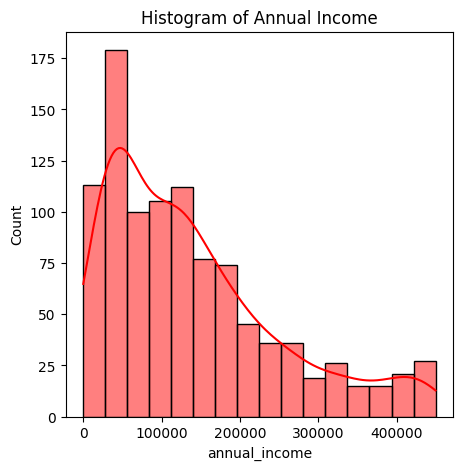

In [17]:
plt.figure(figsize= (5,5))
sns.histplot(df_cust['annual_income'],kde=True,color='red',label='Data')
plt.title("Histogram of Annual Income")
plt.show()

# Treating Outliers


In [18]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,138916.765500
std,288.819436,15.666155,110969.408643
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,48229.500000
50%,500.500000,32.000000,113416.000000
75%,750.250000,46.000000,192614.000000
max,1000.000000,135.000000,449346.000000


In [19]:
# let us assume that it has been informed that the annual income has to be atleast 100. So, will find the record where ann inc is less than 100
df_cust[df_cust['annual_income']<100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Gambhir,Male,50,City,Business Owner,50.0,Married
262,263,Veer Rathod,Male,53,Suburb,Business Owner,50.0,Married
316,317,Avinash Chauhan,Male,47,City,Consultant,50.0,Married
333,334,Samaira D'Souza,Female,29,City,Data Scientist,50.0,Married
340,341,Ridhi Rastogi,Female,33,Rural,Fullstack Developer,50.0,Married
543,544,Gauri Gupta,Male,54,City,Consultant,2.0,Married
592,593,Vivaan Pande,Female,32,City,Business Owner,50.0,Married
633,634,Aradhya Pandey,Male,26,City,Data Scientist,2.0,Married
686,687,Gauri Nanda,Male,40,City,Business Owner,2.0,Married
696,697,Avani Lalwani,Male,47,City,Consultant,20.0,Married


In [20]:
def get_low_income(row):
    if row['annual_income']<100:
        return occ_median[row['occupation']]
    else:
        return row['annual_income']

In [21]:
df_cust['annual_income'] = df_cust.apply(get_low_income,axis =1)
df_cust.head(20)

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married
5,6,Aditi Kaul,Male,22,City,Freelancer,44887.0,Married
6,7,Aisha Mittal,Female,32,Suburb,Business Owner,259013.0,Married
7,8,Aarya Choudhary,Male,27,City,Freelancer,159400.0,Married
8,9,Simran Naidu,Male,21,Suburb,Fullstack Developer,34814.0,Single
9,10,Rishabh Bhat,Male,25,Rural,Freelancer,39832.0,Married


In [22]:
df_cust.iloc[[31,316,333]] # checking if replacement is working or not

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Gambhir,Male,50,City,Business Owner,261191.5,Married
316,317,Avinash Chauhan,Male,47,City,Consultant,58017.0,Married
333,334,Samaira D'Souza,Female,29,City,Data Scientist,135759.0,Married


# Visualizing Annual Income

In [24]:
avg_annual_inc_occup_wise = df_cust.groupby('occupation')['annual_income'].mean()
avg_annual_inc_occup_wise


occupation
Accountant              64123.562500
Artist                  45309.236842
Business Owner         268447.368512
Consultant              60703.154639
Data Scientist         137021.266304
Freelancer              76327.508772
Fullstack Developer     78727.972973
Name: annual_income, dtype: float64

In [26]:
avg_annual_inc_occup_wise.index,
avg_annual_inc_occup_wise.values

array([ 64123.5625    ,  45309.23684211, 268447.36851211,  60703.15463918,
       137021.26630435,  76327.50877193,  78727.97297297])

C:\Users\Ashok\AppData\Local\Temp\ipykernel_30928\1269059230.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_annual_inc_occup_wise.index,y=avg_annual_inc_occup_wise.values,palette = 'tab10')


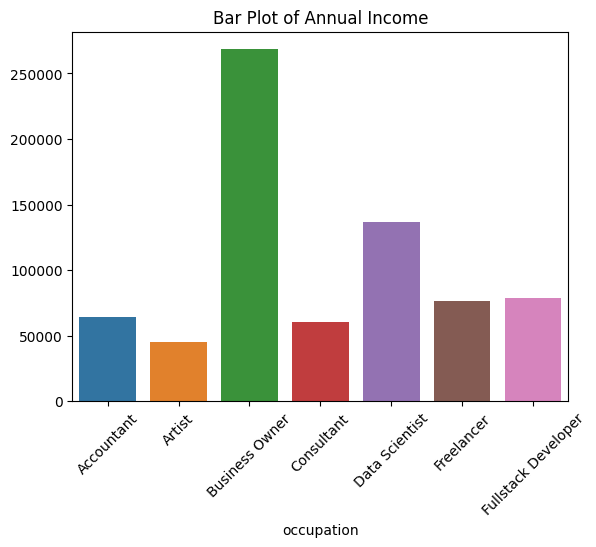

In [28]:
sns.barplot(x=avg_annual_inc_occup_wise.index,y=avg_annual_inc_occup_wise.values,palette = 'tab10')
plt.xticks(rotation= 45)
plt.title("Bar Plot of Annual Income")
plt.savefig("bar_plot_Annual_Income.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
cat_col = ['gender','location',	'occupation','marital_status']
import warnings
warnings.filterwarnings("ignore")

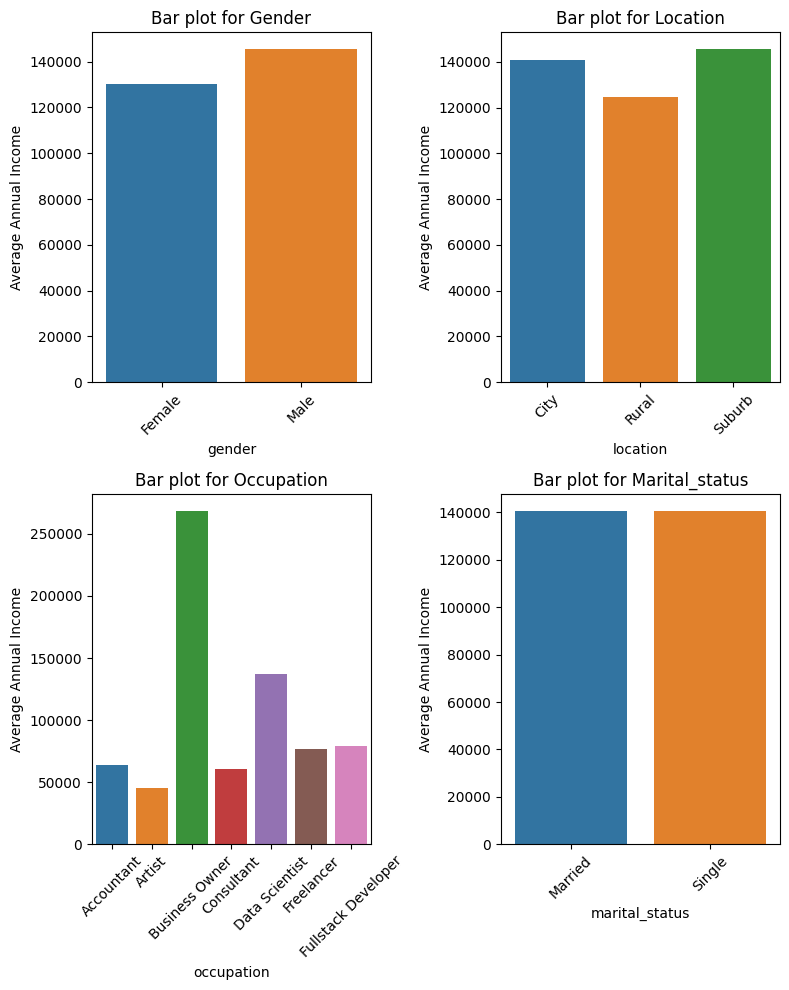

In [31]:
#for col in cat_col:
    #plt.figure(figsize= (5,4))
no_rows=2
colm=2
fig,axes = plt.subplots(no_rows,colm,figsize= (8,5*no_rows))
axes = axes.flatten()
for i, col in enumerate(cat_col):
    avg_income_per_group = df_cust.groupby(col)['annual_income'].mean()
        
    sns.barplot(
        x=avg_income_per_group.index,
        y=avg_income_per_group.values,
        palette='tab10',
        ax=axes[i]
        )
        
    axes[i].set_xticklabels(avg_income_per_group.index, rotation=45)
    axes[i].set_title(f"Bar plot for {col.capitalize()}")
    axes[i].set_ylabel('Average Annual Income')
    
plt.tight_layout()
fig.savefig(
    "visuals/average_income_by_category.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### In our customers’ dataframe, the age column has some outliers. Also age is valid only if it is between 15 and 80 years.

In [32]:
df_cust.describe() # it shows min age =1 amd max age =135 which are obviously not valid.

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,140483.548500
std,288.819436,15.666155,110463.002934
min,1.000000,1.000000,5175.000000
25%,250.750000,26.000000,49620.500000
50%,500.500000,32.000000,115328.000000
75%,750.250000,46.000000,195514.250000
max,1000.000000,135.000000,449346.000000


In [33]:
df_cust[(df_cust['age']<15) | (df_cust['age']>80)].shape[0] # there are 20 records which are in invalid age range.

20

#### Removal/treatment of invalid age records-- we will retain these values but replace the invalid age with the median but median will be decided based on corresponding occupation.

In [34]:
median_age_occ = df_cust.groupby('occupation')['age'].median()
median_age_occ
median_age_occ.values.astype(int)

array([31, 26, 51, 46, 32, 24, 27])

In [35]:
def invalid_age_removal(row):
    if (row['age']<15) | (row['age']>80):
        return int(median_age_occ[row['occupation']])
    else:
        return int(row['age'])

In [36]:
df_cust['age'] = df_cust.apply(invalid_age_removal,axis = 1)
df_cust.age.describe()

count    1000.000000
mean       35.539000
std        12.277998
min        18.000000
25%        26.000000
50%        32.000000
75%        44.250000
max        64.000000
Name: age, dtype: float64

Lets check whether we have any record with age less than 15 and greater than 80.

In [37]:
df_cust[(df_cust['age']<15) | (df_cust['age']>80)]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


Now, we have no outliers left.

In [38]:
# Another way to write the above function using lambda function
df_cust['age'] = df_cust.apply(
    lambda row: int(median_age_occ[row['occupation']]) if (row['age']<15) | (row['age']>80) else int(row['age']) , axis = 1
)

In [39]:
df_cust.head(10)

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married
5,6,Aditi Kaul,Male,22,City,Freelancer,44887.0,Married
6,7,Aisha Mittal,Female,32,Suburb,Business Owner,259013.0,Married
7,8,Aarya Choudhary,Male,27,City,Freelancer,159400.0,Married
8,9,Simran Naidu,Male,21,Suburb,Fullstack Developer,34814.0,Single
9,10,Rishabh Bhat,Male,25,Rural,Freelancer,39832.0,Married


# Data Visualization: Age Column

In [40]:
# define the custom bin edge

bin_edge = [18,25,33,42,50,60,80]
bin_labels = ['18-25','26-33','34-42','43-50','51-60','61-80']
df_cust['age_grouped'] = pd.cut(df_cust['age'],bins = bin_edge,labels = bin_labels,right = True)
df_cust.head()


,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_grouped
0,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,51-60
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single,43-50
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married,18-25
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married,18-25
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married,43-50


In [43]:
age_group_count = (df_cust['age_grouped'].value_counts(normalize = True)*100).round(2)
age_group_count

age_grouped
26-33    30.76
18-25    23.45
34-42    18.17
51-60    12.18
43-50    11.37
61-80     4.06
Name: proportion, dtype: float64

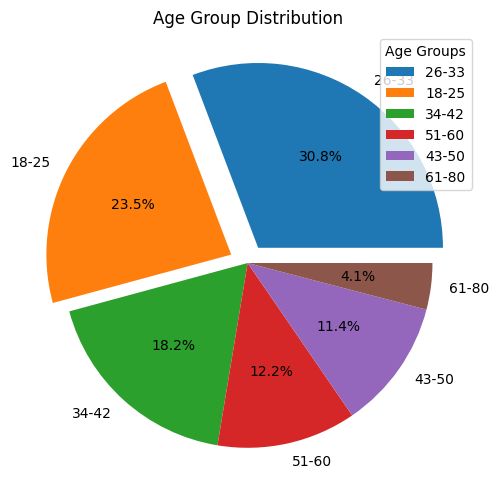

In [50]:
# Pie-chart Visualization

plt.figure(figsize=(9, 6))
plt.pie(age_group_count,
       autopct = '%1.1f%%',
       explode = [0.1,0.1,0,0,0,0],
       labels = age_group_count.index
       )
plt.title("Age Group Distribution")
plt.legend(age_group_count.index, title="Age Groups", loc="upper right")
plt.savefig("visuals/Age_group_distribution.png",dpi=300,
    bbox_inches="tight")
plt.show()

 Above Pie Chart for Age group distribution shows that customer base between age range 18-25 & 26-33 is greater than 54%. after that age percentage in groups '34-42' and '51-60' are 18.2% and 12.2% respectively.

# Analysis of Location and Gender

In [51]:
# Types of location & gender and their Count
# # converts the MultiIndex Series into a DataFrame — where:

# Rows = location

# Columns = gender

# Values = counts

cust_loc_gender = df_cust[['location','gender']].value_counts().unstack(fill_value=0)

cust_loc_gender
#type(cust_loc_gender)


gender,Female,Male
location,,
City,226,457
Rural,26,59
Suburb,74,158


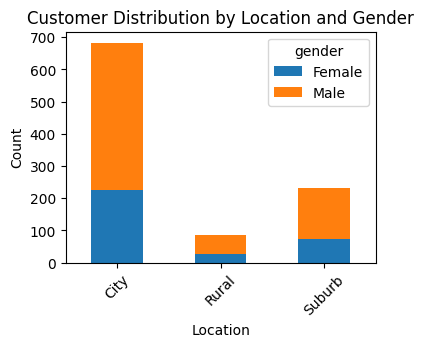

In [53]:
cust_loc_gender.plot(kind='bar',stacked =True,figsize=(4,3))
plt.title('Customer Distribution by Location and Gender')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.savefig("visuals/Customer Distribution by Location and Gender.png",dpi=300,
    bbox_inches="tight")
plt.show()

### Explore Credit Score Table

In [74]:
df_credit.shape

(1004, 6)

In [75]:
df_credit.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
count,1004.000000,1004.000000,1000.000000,1000.000000,1000.000000,935.000000
mean,500.850598,588.655378,0.498950,9683.597000,1.955000,19235.561497
std,288.315670,152.575244,0.233139,25255.893671,1.414559,24489.997195
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.000000
25%,251.750000,459.000000,0.293917,221.000000,1.000000,750.000000
50%,502.500000,601.000000,0.487422,550.000000,2.000000,1250.000000
75%,749.250000,737.250000,0.697829,11819.500000,3.000000,40000.000000
max,1000.000000,799.000000,0.899648,209901.000000,4.000000,60000.000000


In [76]:
df_credit.shape

(1004, 6)

shape of df_credit dataframe shows that it has 1004 rows while df_cust had 1000 rows. This suggests that there would be some duplicate rows in df_credit. Lets find out.

In [77]:
df_credit.nunique()

cust_id                           1000
credit_score                       419
credit_utilisation                1000
outstanding_debt                   781
credit_inquiries_last_6_months       5
credit_limit                         8
dtype: int64

In [78]:
df_credit.duplicated('cust_id')

0       False
1       False
2       False
3       False
4       False
        ...  
999     False
1000    False
1001    False
1002    False
1003    False
Length: 1004, dtype: bool

In [79]:
df_credit[df_credit.duplicated('cust_id',keep = False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
516,517,308,NaN,NaN,NaN,NaN
517,517,308,0.113860,33.0,3.0,500.0
569,569,344,NaN,NaN,NaN,NaN
570,569,344,0.112599,37.0,0.0,500.0
607,606,734,NaN,NaN,NaN,NaN
608,606,734,0.193418,4392.0,1.0,40000.0
664,662,442,NaN,NaN,NaN,NaN
665,662,442,0.856039,266.0,2.0,500.0


In [80]:
#It shows that index 516,569,607,664 have duplicate rows/records which need to be removed.

In [81]:
df_credit_clean = df_credit.drop_duplicates('cust_id',keep = 'last')
df_credit_clean # it shows dataframe after removing the duplicate rows. Total no of rows now is 1000.

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0
...,...,...,...,...,...,...
999,996,564,0.702963,688.0,2.0,1250.0
1000,997,774,0.465462,17139.0,0.0,60000.0
1001,998,529,0.585856,386.0,3.0,1000.0
1002,999,725,0.249670,6973.0,2.0,40000.0


In [82]:
#Checking Null values
df_credit_clean.isnull().sum()

cust_id                            0
credit_score                       0
credit_utilisation                 0
outstanding_debt                   0
credit_inquiries_last_6_months     0
credit_limit                      65
dtype: int64

There are some missing values in the credit_limit column. Since a customer’s credit limit usually depends on their credit score, let’s explore the relationship between these two variables. Then, we’ll use the credit score to fill in the missing credit limit values.

In [83]:
df_credit_clean[df_credit_clean['credit_limit'].isnull()]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
10,11,679,0.557450,9187.0,2.0,NaN
35,36,790,0.112535,4261.0,1.0,NaN
37,38,514,0.296971,238.0,2.0,NaN
45,46,761,0.596041,24234.0,2.0,NaN
64,65,734,0.473715,13631.0,0.0,NaN
...,...,...,...,...,...,...
912,909,479,0.487555,320.0,3.0,NaN
931,928,311,0.832244,316.0,2.0,NaN
948,945,526,0.272734,227.0,1.0,NaN
954,951,513,0.175914,131.0,3.0,NaN


In [84]:
df_credit_clean['credit_limit'].unique()

array([40000.,  1250.,  1000.,   500.,   750.,    nan,  1500., 60000.,
       20000.])

In [85]:
df_credit_clean['credit_limit'].value_counts()

credit_limit
500.0      229
60000.0    186
40000.0    137
1500.0     100
1000.0      90
750.0       76
1250.0      75
20000.0     42
Name: count, dtype: int64

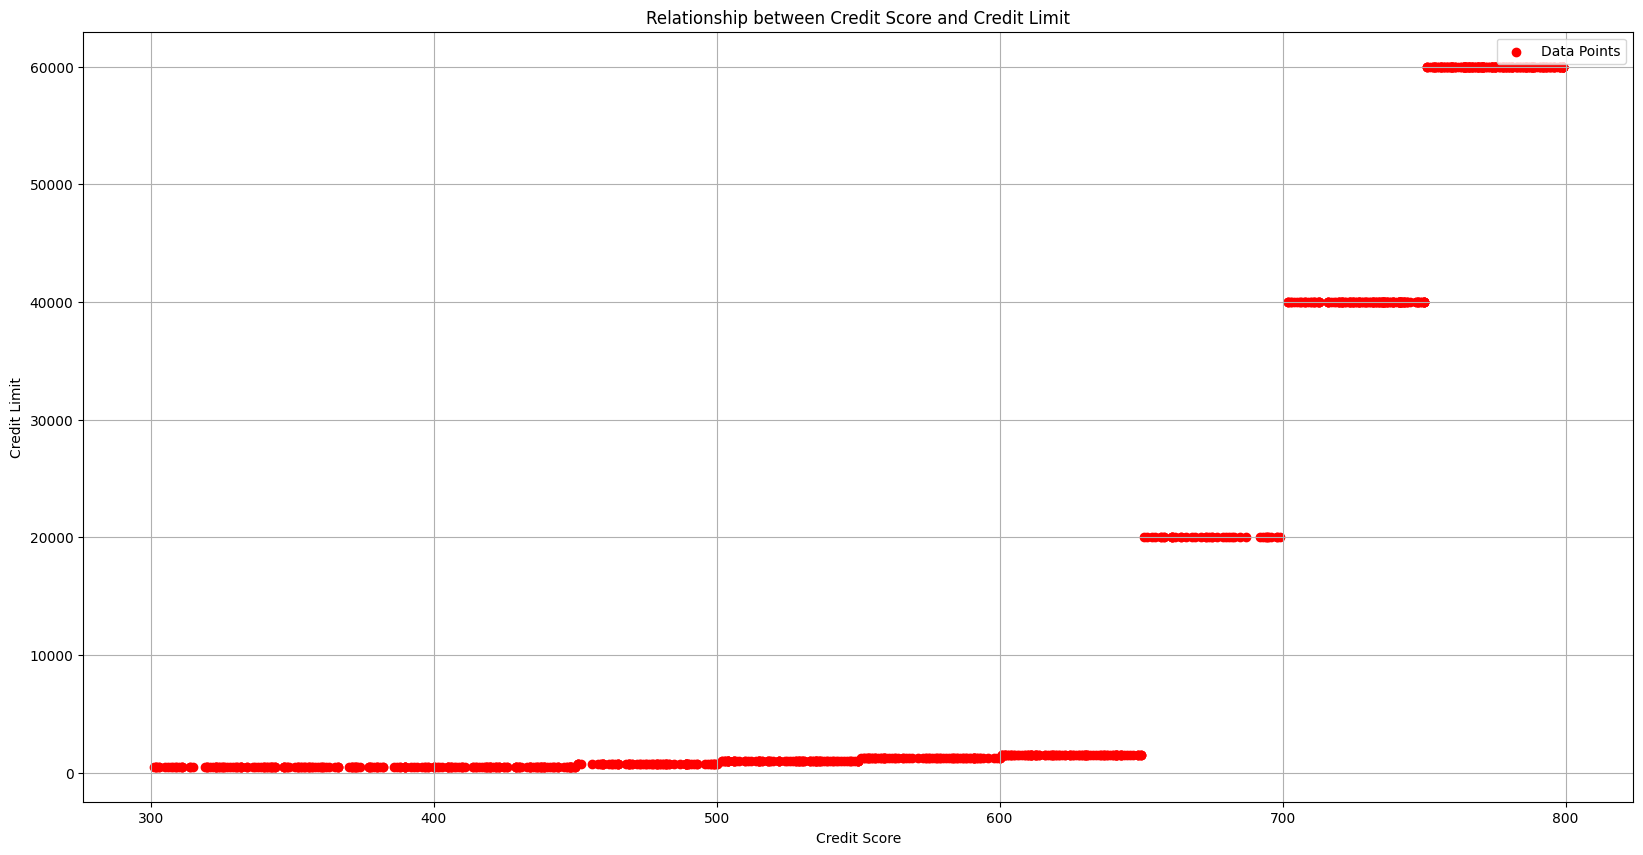

In [86]:
# lets plot scatter plot between credit_score and credit_limit

plt.figure(figsize=(20,10))
plt.scatter(x=df_credit_clean['credit_score'],y=df_credit_clean['credit_limit'],label = 'Data Points',c='red')
plt.grid(True)
plt.xlabel('Credit Score')
plt.ylabel('Credit Limit')
plt.title('Relationship between Credit Score and Credit Limit')
plt.legend()
plt.savefig("visuals/Scatter_plot_credit_score_and_credit_limit.png")
plt.show()

It can be clearly seen that there is a positive relationship between credit score and credit limit but it’s not continuous rather, the credit limit seems to change in discrete blocks. It can be interpreted: if Credit score < 600 → Low credit limit (≈0–1,000), if credit score is between 650–700 → Medium credit limit (≈20,000), if  credit score is between 700–750 → credit  limit (≈40,000) and if  credit score is between 750–800 → credit  limit (≈60,000)

In [87]:
# Define bin ranges
bin_ranges = [300, 450, 500, 550, 600, 650, 700, 750, 800]

bin_labels = [f'{bin_ranges[i]}–{bin_ranges[i+1]-1}' for i in range(len(bin_ranges)-1)]
bin_labels

# df_credit_clean['credit_score_range'] = pd.cut(
#     df_credit_clean['credit_score'],
#     bins=bin_ranges,
#     labels=bin_labels,
#     include_lowest=True
# )

['300–449',
 '450–499',
 '500–549',
 '550–599',
 '600–649',
 '650–699',
 '700–749',
 '750–799']

In [88]:
df_credit_clean['credit_score_range'] = pd.cut(
    df_credit_clean['credit_score'],
    bins=bin_ranges,
    labels=bin_labels,
    include_lowest=True
)

In [89]:
df_credit_clean.head() 

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
0,1,749,0.585171,19571.0,0.0,40000.0,700–749
1,2,587,0.107928,161644.0,2.0,1250.0,550–599
2,3,544,0.854807,513.0,4.0,1000.0,500–549
3,4,504,0.336938,224.0,2.0,1000.0,500–549
4,5,708,0.586151,18090.0,2.0,40000.0,700–749


A new column credit_score_range has been created containing range of credit scores

In [90]:
# verification 
df_credit_clean['credit_score_range'].value_counts()

credit_score_range
300–449    240
750–799    207
700–749    148
600–649    105
500–549     97
450–499     82
550–599     78
650–699     43
Name: count, dtype: int64

In [91]:
df_credit_clean[df_credit_clean['credit_score']==800]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range


we need to fill the missing vales for credit_limit column based on credit_score_range.Variable credit_limit takes discrete or fixed values such as 0, 10,000, 20,000, 40,000, 60,000. In such case, we can use MODE to find out most frequently occuring credit limit for a given score range.

In [92]:
g = df_credit_clean.groupby('credit_score_range')['credit_limit'].agg(lambda x : x.mode().iloc[0]).reset_index()
g

,credit_score_range,credit_limit
0,300–449,500.0
1,450–499,750.0
2,500–549,1000.0
3,550–599,1250.0
4,600–649,1500.0
5,650–699,20000.0
6,700–749,40000.0
7,750–799,60000.0


In [93]:
df_credit_clean['credit_limit_mode'] = df_credit_clean.groupby('credit_score_range')['credit_limit'].transform(lambda x : x.mode().iloc[0])
df_credit_clean['credit_limit_mode']
df_credit_clean[df_credit_clean['credit_limit'].isnull()]


,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
10,11,679,0.557450,9187.0,2.0,NaN,650–699,20000.0
35,36,790,0.112535,4261.0,1.0,NaN,750–799,60000.0
37,38,514,0.296971,238.0,2.0,NaN,500–549,1000.0
45,46,761,0.596041,24234.0,2.0,NaN,750–799,60000.0
64,65,734,0.473715,13631.0,0.0,NaN,700–749,40000.0
...,...,...,...,...,...,...,...,...
912,909,479,0.487555,320.0,3.0,NaN,450–499,750.0
931,928,311,0.832244,316.0,2.0,NaN,300–449,500.0
948,945,526,0.272734,227.0,1.0,NaN,500–549,1000.0
954,951,513,0.175914,131.0,3.0,NaN,500–549,1000.0


In [94]:
df_credit_clean1= df_credit_clean.copy()

In [95]:
# Fill the Null values of credit_limit with the credit_limit_mode
df_credit_clean1['credit_limit'] = df_credit_clean1['credit_limit'].fillna(df_credit_clean1['credit_limit_mode'])
df_credit_clean1[['credit_limit']].iloc[[10,37,35,45]]

,credit_limit
10,20000.0
37,1000.0
35,60000.0
45,60000.0


In [96]:
# verification of missing values in credit_limit
df_credit_clean1[['credit_limit']].isna().sum()


credit_limit    0
dtype: int64

In [97]:
df_credit_clean1.isnull().sum()

cust_id                           0
credit_score                      0
credit_utilisation                0
outstanding_debt                  0
credit_inquiries_last_6_months    0
credit_limit                      0
credit_score_range                0
credit_limit_mode                 0
dtype: int64

We have removed all outliers and missing values

In [98]:
# verification
df_credit_clean1[df_credit_clean1.cust_id==65]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
64,65,734,0.473715,13631.0,0.0,40000.0,700–749,40000.0


# Checking for other Outliers

In [99]:
df_credit_clean1.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_limit_mode
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,589.182000,0.498950,9683.597000,1.955000,19733.500000,19733.500000
std,288.819436,152.284929,0.233139,25255.893671,1.414559,24717.629112,24717.629112
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.000000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,750.000000,750.000000
50%,500.500000,601.500000,0.487422,550.000000,2.000000,1500.000000,1500.000000
75%,750.250000,738.000000,0.697829,11819.500000,3.000000,40000.000000,40000.000000
max,1000.000000,799.000000,0.899648,209901.000000,4.000000,60000.000000,60000.000000


After going through the min and max for outstanding_debt column, it can be observed that max value is 209901.00 which is greater than maximum credit_limit value i.e 60000. It is obvious that outstanding_debt cannot be greater than credit_limit. Therefore, we need to handle the outliers in outstanding_debt column. Instead of using any statistical approach to find the outliers, we will use business domain knowledge here.

In [100]:
# we will find the outstanding_debt values greater than credit_limit.
outstanding_debt_outliers = df_credit_clean1[(df_credit_clean1.outstanding_debt > df_credit_clean1.credit_limit )]
outstanding_debt_outliers

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
1,2,587,0.107928,161644.0,2.0,1250.0,550–599,1250.0
19,20,647,0.439132,205014.0,3.0,1500.0,600–649,1500.0
25,26,758,0.250811,190838.0,2.0,60000.0,750–799,60000.0
38,39,734,0.573023,122758.0,3.0,40000.0,700–749,40000.0
93,94,737,0.739948,137058.0,2.0,40000.0,700–749,40000.0
204,205,303,0.364360,187849.0,0.0,500.0,300–449,500.0
271,272,703,0.446886,154568.0,1.0,40000.0,700–749,40000.0
301,302,722,0.608076,122402.0,4.0,40000.0,700–749,40000.0
330,331,799,0.363420,208898.0,4.0,60000.0,750–799,60000.0
350,351,320,0.285081,150860.0,0.0,500.0,300–449,500.0


In [101]:
df_credit_clean1[(df_credit_clean1.outstanding_debt > df_credit_clean1.credit_limit )].shape[0]

20

There are 20 such records where outstanding_debt values greater than credit_limit. We need to treat them. we will replace them with their credit_limt values.

In [102]:
df_credit_clean1.loc[(df_credit_clean1.outstanding_debt > df_credit_clean1.credit_limit ), 'outstanding_debt'] = df_credit_clean1.credit_limit

df_credit_clean1[(df_credit_clean1.outstanding_debt > df_credit_clean1.credit_limit )]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode


In [103]:
outstanding_debt_outliers.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
1,2,587,0.107928,161644.0,2.0,1250.0,550–599,1250.0
19,20,647,0.439132,205014.0,3.0,1500.0,600–649,1500.0
25,26,758,0.250811,190838.0,2.0,60000.0,750–799,60000.0
38,39,734,0.573023,122758.0,3.0,40000.0,700–749,40000.0
93,94,737,0.739948,137058.0,2.0,40000.0,700–749,40000.0


In [104]:
df_credit_clean1[df_credit_clean1['cust_id'].isin([2,20,26])]


,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
1,2,587,0.107928,1250.0,2.0,1250.0,550–599,1250.0
19,20,647,0.439132,1500.0,3.0,1500.0,600–649,1500.0
25,26,758,0.250811,60000.0,2.0,60000.0,750–799,60000.0


We have treated all outliers in column outstanding_debt. 

In [105]:
df_credit_clean1.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_limit_mode
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,589.182000,0.498950,6850.084000,1.955000,19733.500000,19733.500000
std,288.819436,152.284929,0.233139,10683.473561,1.414559,24717.629112,24717.629112
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.000000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,750.000000,750.000000
50%,500.500000,601.500000,0.487422,541.500000,2.000000,1500.000000,1500.000000
75%,750.250000,738.000000,0.697829,10924.500000,3.000000,40000.000000,40000.000000
max,1000.000000,799.000000,0.899648,60000.000000,4.000000,60000.000000,60000.000000


## Exploring and Visualizing Correlation in Credit Score Table

In [106]:
df_credit_clean1.head(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,749,0.585171,19571.0,0.0,40000.0,700–749,40000.0
1,2,587,0.107928,1250.0,2.0,1250.0,550–599,1250.0
2,3,544,0.854807,513.0,4.0,1000.0,500–549,1000.0


In [107]:
df_cust.head(3)

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_grouped
0,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,51-60
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single,43-50
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married,18-25


In [108]:
## We will merge these two tables in order to find various correlation

df_merged = df_cust.merge(df_credit_clean1,on = 'cust_id',how = 'inner')
df_merged.head()


,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_grouped,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,51-60,749,0.585171,19571.0,0.0,40000.0,700–749,40000.0
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single,43-50,587,0.107928,1250.0,2.0,1250.0,550–599,1250.0
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married,18-25,544,0.854807,513.0,4.0,1000.0,500–549,1000.0
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married,18-25,504,0.336938,224.0,2.0,1000.0,500–549,1000.0
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married,43-50,708,0.586151,18090.0,2.0,40000.0,700–749,40000.0


In [109]:
df_merged.shape

(1000, 16)

In [110]:
# Columns to be considered
corr_columns = ['credit_score','credit_utilisation','outstanding_debt','credit_limit','age','annual_income']
corr_matrix = df_merged[corr_columns].corr()
corr_matrix

,credit_score,credit_utilisation,outstanding_debt,credit_limit,age,annual_income
credit_score,1.000000,-0.070445,0.680654,0.847951,0.444961,0.575751
credit_utilisation,-0.070445,1.000000,0.192838,-0.080504,-0.027828,-0.086368
outstanding_debt,0.680654,0.192838,1.000000,0.810581,0.444375,0.555661
credit_limit,0.847951,-0.080504,0.810581,1.000000,0.511078,0.684780
age,0.444961,-0.027828,0.444375,0.511078,1.000000,0.619103
annual_income,0.575751,-0.086368,0.555661,0.684780,0.619103,1.000000


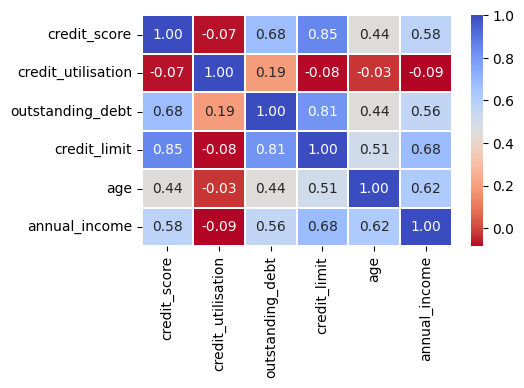

In [112]:
# to make correlation table more readable, we will create heatmap

plt.figure(figsize = (5,3))

sns.heatmap(
    corr_matrix, 
    annot = True,
    fmt = '.2f',
    cmap = "coolwarm_r",
    linewidth = 0.05
)
plt.savefig('visuals/Correlation_matrix.png')
plt.show()


There is high correlation between credit score and credit limit i.e 0.85.
Also, Annual income and credit limit is positively related.
Age and annual income are positively related too.

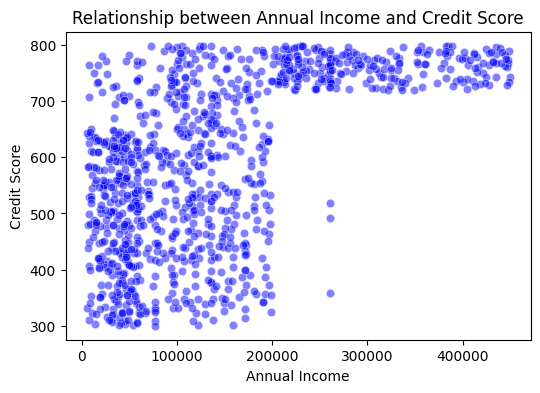

In [114]:
# Ploting relationship between credit_score and annual_income.
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='annual_income',
    y='credit_score',
    data=df_merged,
    color='blue',
    alpha=0.5
)
plt.title('Relationship between Annual Income and Credit Score')
plt.xlabel('Annual Income')
plt.ylabel('Credit Score')
plt.savefig('visuals/scatterplot_annual_income_and_credit_score.png')
plt.show()

From the above scatter plot, the patter can't be clearly interpreted.
It can be observed that higher income doesn’t necessarily mean higher credit score.
Many low income customers also have high credit scores, implying that creditworthiness isn’t solely dependent on income.

<h1 style="color:green" align="center">Exploring Transactions Table<h1>

In [115]:
df_tran.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [116]:
df_tran.shape

(500000, 7)

# Data preprocessing: Checking for missing values, outliers etc.

In [117]:
df_tran.isnull().sum()

tran_id                0
cust_id                0
tran_date              0
tran_amount            0
platform            4941
product_category       0
payment_type           0
dtype: int64

In [118]:
df_tran[df_tran.platform.isnull()]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
355,356,58,2023-01-01,237,NaN,Electronics,Net Banking
418,419,383,2023-01-01,338,NaN,Electronics,Credit Card
607,608,421,2023-01-01,700,NaN,Electronics,Phonepe
844,845,945,2023-01-01,493,NaN,Sports,Credit Card
912,913,384,2023-01-01,85,NaN,Fashion & Apparel,Phonepe
...,...,...,...,...,...,...,...
499579,499580,924,2023-09-05,31,NaN,Fashion & Apparel,Gpay
499646,499647,944,2023-09-05,58445,NaN,Fashion & Apparel,Phonepe
499725,499726,620,2023-09-05,15,NaN,Sports,Net Banking
499833,499834,616,2023-09-05,97,NaN,Fashion & Apparel,Credit Card


There are 4941 records where platform column has Null values.
In order to handle the missing values in platform, we will find the most common platform used for transaction across different product categories in the given table and replace the missing values with it.

In [119]:
df_tran['platform'].value_counts(dropna=False)

platform
Amazon      151443
Flipkart    122660
Alibaba      73584
Meesho       73271
Shopify      39416
Cred         24741
Ebay          9944
NaN           4941
Name: count, dtype: int64

# In general, Amazon has the highest transaction under platform column.
We will fill missing values in the platform column based on the most common (mode) platform within each product_category.
Lets visualize it through countplot.

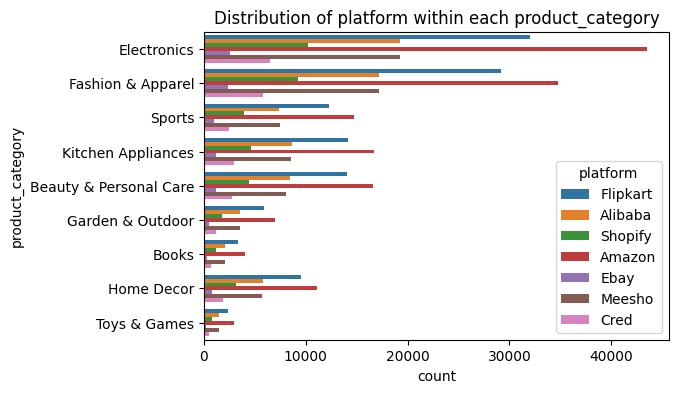

In [121]:
plt.figure(figsize=(6,4))

plt.title('Distribution of platform within each product_category')
plt.ylabel('product_category')
sns.countplot(hue='platform',y='product_category',data=df_tran)
plt.savefig("visuals/Distribution_of_platform_within_each_product_category.png")
plt.show()

It can be seen that transactions on Amazon is maximum within each product category.
For handling null values in platform, we can replace them with "Amazon" as a product platform because it is the most frequently used platform for making transactions.

In [122]:
df_tran.platform.mode()

0    Amazon
Name: platform, dtype: object

In [123]:
df_tran.platform.fillna(df_tran.platform.mode()[0],inplace = True)
df_tran[df_tran.platform.isnull()]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type


Now we have successfully handled all the missing values in platform columns

In [124]:
df_tran.isnull().sum()

tran_id             0
cust_id             0
tran_date           0
tran_amount         0
platform            0
product_category    0
payment_type        0
dtype: int64

# we will check for Outliers

In [125]:
df_tran.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.00000
mean,250000.500000,501.400428,3225.20733
std,144337.711635,288.641924,13098.74276
min,1.000000,1.000000,0.00000
25%,125000.750000,252.000000,64.00000
50%,250000.500000,502.000000,141.00000
75%,375000.250000,752.000000,397.00000
max,500000.000000,1000.000000,69999.00000


The min value is 0 in tran_amount which seems to be invalid.

In [127]:
df_tran_zero = df_tran[df_tran.tran_amount==0]
df_tran_zero

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
120,121,440,2023-01-01,0,Amazon,Electronics,Credit Card
141,142,839,2023-01-01,0,Amazon,Electronics,Credit Card
517,518,147,2023-01-01,0,Amazon,Electronics,Credit Card
533,534,891,2023-01-01,0,Amazon,Electronics,Credit Card
586,587,108,2023-01-01,0,Amazon,Electronics,Credit Card
...,...,...,...,...,...,...,...
499326,499327,695,2023-09-05,0,Amazon,Electronics,Credit Card
499494,499495,295,2023-09-05,0,Amazon,Electronics,Credit Card
499708,499709,141,2023-09-05,0,Amazon,Electronics,Credit Card
499928,499929,4,2023-09-05,0,Amazon,Electronics,Credit Card


In [128]:
df_tran_zero.value_counts().sum()

4734

In [129]:
df_grouped = df_tran_zero.groupby(['platform', 'product_category']).size().reset_index(name='count')
df_grouped

,platform,product_category,count
0,Amazon,Electronics,4734


In [130]:
df_tran_zero[['platform','product_category','payment_type']].value_counts()

platform  product_category  payment_type
Amazon    Electronics       Credit Card     4734
Name: count, dtype: int64

It becomes quite obvious that the zero transaction value in tran_amount column is only prevailing when the platform is Amazon,product_category is Electronics and  payment_type is Credit card. Therefore, We need to find the transactions with same criteria across platform,product_category and payment_type and replace these zero values with their median.

In [131]:
df_tran_1 = df_tran[(df_tran.platform =="Amazon") & (df_tran.product_category == 'Electronics') & (df_tran.payment_type == 'Credit Card')]
df_tran_1

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
109,110,887,2023-01-01,635,Amazon,Electronics,Credit Card
120,121,440,2023-01-01,0,Amazon,Electronics,Credit Card
141,142,839,2023-01-01,0,Amazon,Electronics,Credit Card
173,174,676,2023-01-01,60439,Amazon,Electronics,Credit Card
190,191,763,2023-01-01,697,Amazon,Electronics,Credit Card
...,...,...,...,...,...,...,...
499812,499813,688,2023-09-05,425,Amazon,Electronics,Credit Card
499860,499861,373,2023-09-05,480,Amazon,Electronics,Credit Card
499885,499886,520,2023-09-05,643,Amazon,Electronics,Credit Card
499928,499929,4,2023-09-05,0,Amazon,Electronics,Credit Card


In [132]:
df_tran_1.shape

(15637, 7)

In [133]:
df_tran_2 = df_tran_1[df_tran_1.tran_amount > 0]
df_tran_2

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
109,110,887,2023-01-01,635,Amazon,Electronics,Credit Card
173,174,676,2023-01-01,60439,Amazon,Electronics,Credit Card
190,191,763,2023-01-01,697,Amazon,Electronics,Credit Card
263,264,528,2023-01-01,421,Amazon,Electronics,Credit Card
311,312,936,2023-01-01,537,Amazon,Electronics,Credit Card
...,...,...,...,...,...,...,...
499766,499767,723,2023-09-05,909,Amazon,Electronics,Credit Card
499793,499794,586,2023-09-05,304,Amazon,Electronics,Credit Card
499812,499813,688,2023-09-05,425,Amazon,Electronics,Credit Card
499860,499861,373,2023-09-05,480,Amazon,Electronics,Credit Card


In [134]:
df_tran_2.shape


(10903, 7)

In [135]:
median_tran_2 = df_tran_2.tran_amount.median()
median_tran_2

554.0

In [136]:
df_tran.replace(0,median_tran_2,inplace = True)

In [137]:
# Verification
df_tran[df_tran.tran_amount == 0]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type


In [138]:
df_tran.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.000000
mean,250000.500000,501.400428,3230.452602
std,144337.711635,288.641924,13097.561071
min,1.000000,1.000000,2.000000
25%,125000.750000,252.000000,66.000000
50%,250000.500000,502.000000,146.000000
75%,375000.250000,752.000000,413.000000
max,500000.000000,1000.000000,69999.000000


## tran_amount column has no zero values now.

In [139]:
df_tran[df_tran.tran_amount<1000]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking
...,...,...,...,...,...,...,...
499994,499995,679,2023-09-05,59,Ebay,Beauty & Personal Care,Gpay
499995,499996,791,2023-09-05,43,Amazon,Books,Phonepe
499997,499998,57,2023-09-05,224,Amazon,Garden & Outdoor,Phonepe
499998,499999,629,2023-09-05,538,Flipkart,Home Decor,Gpay


# Treating Oultliers in trans_amount

<Axes: xlabel='tran_amount', ylabel='Count'>

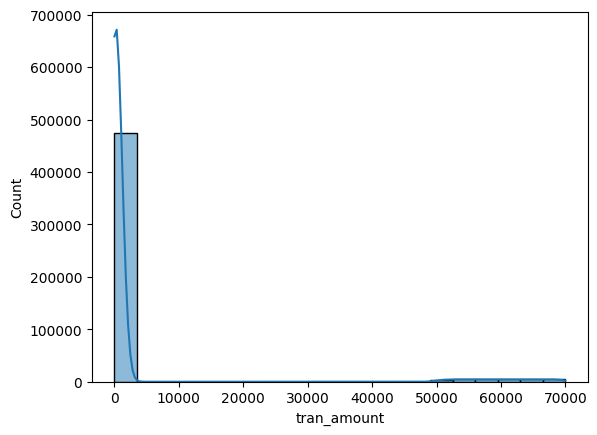

In [142]:
sns.histplot(df_tran.tran_amount,kde= True,bins =20)

In [143]:
df_tran[df_tran.tran_amount<2000].max()

tran_id                   500000
cust_id                     1000
tran_date             2023-09-05
tran_amount                  999
platform                 Shopify
product_category    Toys & Games
payment_type             Phonepe
dtype: object

From the above chart and the maximum value of tran_amount less than 2000 which is 999 indicates that majority of the data values within the coulumn tran_amount lies below 1000. All other values can be considered as outliers. Lets do deep analysis through IQR method.

In [144]:
Q1,Q3 = df_tran.tran_amount.quantile([0.25,0.75])
Q1, Q3

(66.0, 413.0)

In [145]:
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5* IQR

lower,upper

(-454.5, 933.5)

In [146]:
# Considering above approach gives us the upper value as 933.5 which is less than 999. 
# so we will use following:

lower1 = Q1 - 2*IQR
upper1 = Q3 + 2* IQR

lower1,upper1

(-628.0, 1107.0)

We will consider only upper1 value for filtering outliers and lower value will be 2 as per summary of trans_amount. 
It can not be negative.

In [148]:
outlier_tran_amount = df_tran[df_tran.tran_amount>upper1]
outlier_tran_amount

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,61963,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,57869,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,52881,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,58574,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,51669,Shopify,Kitchen Appliances,Credit Card
...,...,...,...,...,...,...,...
499742,499743,868,2023-09-05,55131,Meesho,Fashion & Apparel,Gpay
499888,499889,614,2023-09-05,59679,Meesho,Fashion & Apparel,Net Banking
499900,499901,811,2023-09-05,60184,Flipkart,Sports,Debit Card
499966,499967,662,2023-09-05,54678,Meesho,Sports,Gpay


We have different values in product_category column for which the trans_amount varies too much.
So we will find the mean values of the tran_amount across different product_category

In [149]:
df_tran_1 = df_tran[df_tran.tran_amount<=upper1]
df_tran_1

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking
...,...,...,...,...,...,...,...
499994,499995,679,2023-09-05,59,Ebay,Beauty & Personal Care,Gpay
499995,499996,791,2023-09-05,43,Amazon,Books,Phonepe
499997,499998,57,2023-09-05,224,Amazon,Garden & Outdoor,Phonepe
499998,499999,629,2023-09-05,538,Flipkart,Home Decor,Gpay


In [150]:
mean_tran_amount = df_tran_1.groupby('product_category').tran_amount.mean()
mean_tran_amount

product_category
Beauty & Personal Care     92.167205
Books                      29.553515
Electronics               510.172685
Fashion & Apparel          64.553463
Garden & Outdoor          125.630277
Home Decor                302.487561
Kitchen Appliances        176.773288
Sports                    269.181631
Toys & Games               50.333298
Name: tran_amount, dtype: float64

In [151]:
df_tran.loc[df_tran.tran_amount>upper1]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,61963,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,57869,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,52881,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,58574,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,51669,Shopify,Kitchen Appliances,Credit Card
...,...,...,...,...,...,...,...
499742,499743,868,2023-09-05,55131,Meesho,Fashion & Apparel,Gpay
499888,499889,614,2023-09-05,59679,Meesho,Fashion & Apparel,Net Banking
499900,499901,811,2023-09-05,60184,Flipkart,Sports,Debit Card
499966,499967,662,2023-09-05,54678,Meesho,Sports,Gpay


In [152]:
df_tran.loc[outlier_tran_amount.index]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,61963,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,57869,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,52881,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,58574,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,51669,Shopify,Kitchen Appliances,Credit Card
...,...,...,...,...,...,...,...
499742,499743,868,2023-09-05,55131,Meesho,Fashion & Apparel,Gpay
499888,499889,614,2023-09-05,59679,Meesho,Fashion & Apparel,Net Banking
499900,499901,811,2023-09-05,60184,Flipkart,Sports,Debit Card
499966,499967,662,2023-09-05,54678,Meesho,Sports,Gpay


In [153]:
 # Replacing outliers with mean values
df_tran.loc[outlier_tran_amount.index, 'tran_amount'] = outlier_tran_amount["product_category"].map(mean_tran_amount)


In [154]:
# Verification
df_tran.loc[df_tran['tran_amount'] > upper1]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type


In [155]:
df_tran.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.000000
mean,250000.500000,501.400428,240.672998
std,144337.711635,288.641924,241.696597
min,1.000000,1.000000,2.000000
25%,125000.750000,252.000000,64.553463
50%,250000.500000,502.000000,133.000000
75%,375000.250000,752.000000,349.000000
max,500000.000000,1000.000000,999.000000


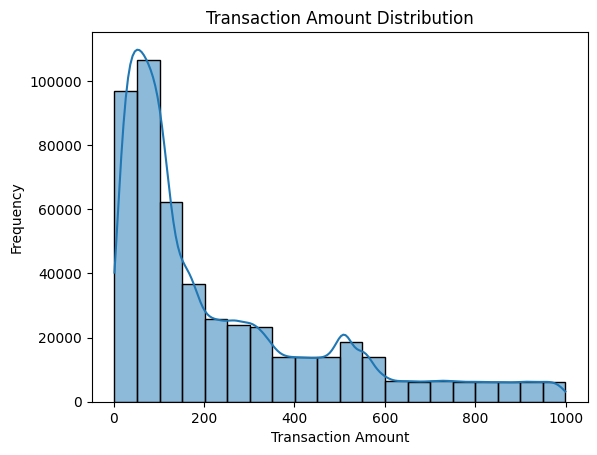

In [156]:
sns.histplot(x='tran_amount', data=df_tran, bins=20, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

# Save figure
plt.savefig("visuals/transaction_amount_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

All outliers in the tran_amount column have been effectively treated.
tran_amount is also less than 1000.
Data distribution is right skewed.

<h2 style="color:blue;">Data Visualization: Payment Type</h2>

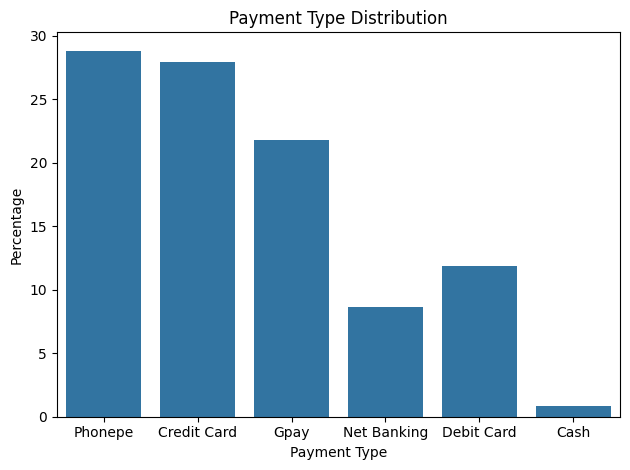

In [157]:
sns.countplot(x = df_tran.payment_type, stat='percent')
plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Percentage")

plt.tight_layout()

# Save the figure
plt.savefig(
    "visuals/payment_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

After phonepe, credit card payment type is most used payment method which is around 27%.

### Distribution of payment_type across age group.
Lets merge df_merged(merged dataframe obtained from df_cust and df_credit_clean1) and df_tran

In [158]:

df_merged_2 = df_merged.merge(df_tran,on= 'cust_id',how = 'inner')
df_merged_2.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_grouped,credit_score,...,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode,tran_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,51-60,749,...,0.0,40000.0,700–749,40000.0,1283,2023-01-01,30.0,Shopify,Fashion & Apparel,Net Banking
1,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,51-60,749,...,0.0,40000.0,700–749,40000.0,1382,2023-01-01,96.0,Amazon,Sports,Debit Card
2,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,51-60,749,...,0.0,40000.0,700–749,40000.0,1521,2023-01-01,86.0,Meesho,Garden & Outdoor,Gpay
3,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,51-60,749,...,0.0,40000.0,700–749,40000.0,1576,2023-01-01,149.0,Amazon,Beauty & Personal Care,Phonepe
4,1,Dhruv Bansal,Female,51,City,Business Owner,358211.0,Married,51-60,749,...,0.0,40000.0,700–749,40000.0,1757,2023-01-01,37.0,Flipkart,Fashion & Apparel,Credit Card


In [159]:
df_merged_2.shape

(500000, 22)

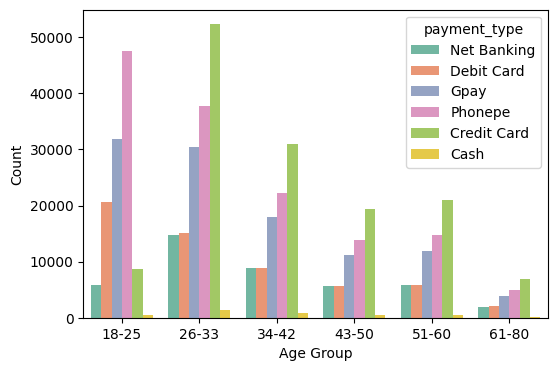

In [161]:
# Plot of distribution of payment_type across age groups
plt.figure(figsize = (6,4))
sns.countplot(hue= 'payment_type',x = 'age_grouped',data = df_merged_2,palette = 'Set2')
plt.xlabel('Age Group')
plt.ylabel("Count")

# Save the figure
plt.savefig(
    "visuals/payment_type_distribution_across_age_group.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

It can be easily inferred from the above graph that the age group 18-25 has the least exposure to credit card payment type as compared to the other age groups.

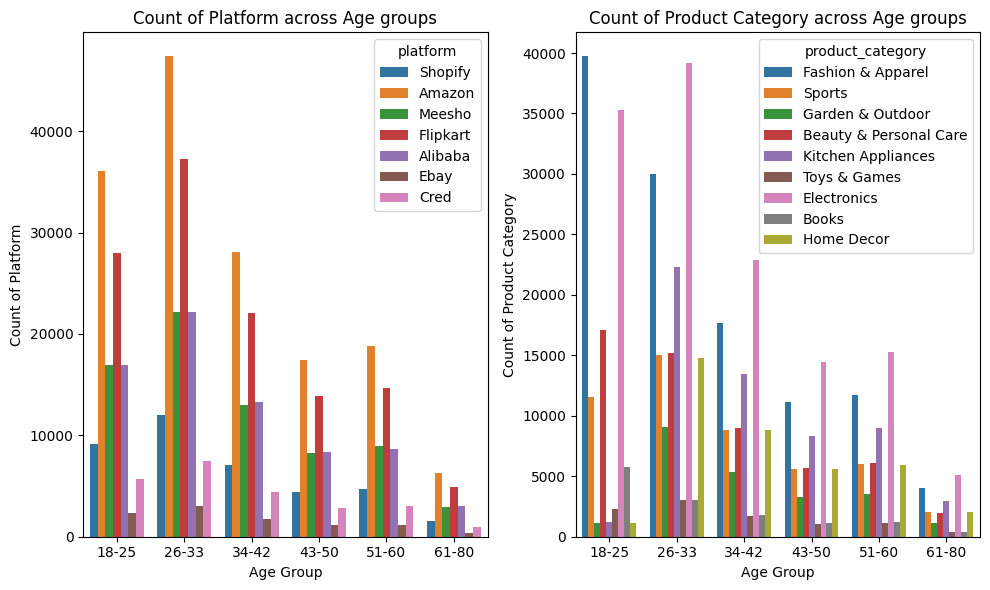

In [162]:
# Count of platform and product category across age groups

fig,axes = plt.subplots(1,2,figsize=(10,6))

sns.countplot(hue='platform',x='age_grouped',data=df_merged_2,ax=axes[0])

sns.countplot(hue='product_category',x='age_grouped',data=df_merged_2,ax=axes[1])

axes[0].set_title('Count of Platform across Age groups')
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Count of Platform")

axes[1].set_title('Count of Product Category across Age groups')
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Count of Product Category")

plt.tight_layout()
plt.savefig("visuals/countof_platform_prod_cat_across_agegroups.png")
plt.show()

### Observation:
1. For Age group 18-25, top three platforms are Amazon,Flipkart and Alibaba(Meesho on same par with Alibaba).
2. Most preferred product category for For Age group 18-25 is Fashion & Apparel which is followed by Electronics and Beauty & personal care

### Data Visualization: Average Transaction Amount

 We will find the average transaction amount for following categorical columns:
1. platform
2. product_category
3. payment_type
4. age_group
5. marital_status

In [163]:
cat_col = ['platform','product_category','payment_type','age_grouped','marital_status']

cat_col_mean={}
for col in cat_col:
    
    cat_col_mean[col] = df_merged_2.groupby(col)['tran_amount'].mean().round(2)
cat_col_mean['platform']



platform
Alibaba     236.86
Amazon      248.01
Cred        238.24
Ebay        235.53
Flipkart    236.90
Meesho      238.04
Shopify     238.17
Name: tran_amount, dtype: float64

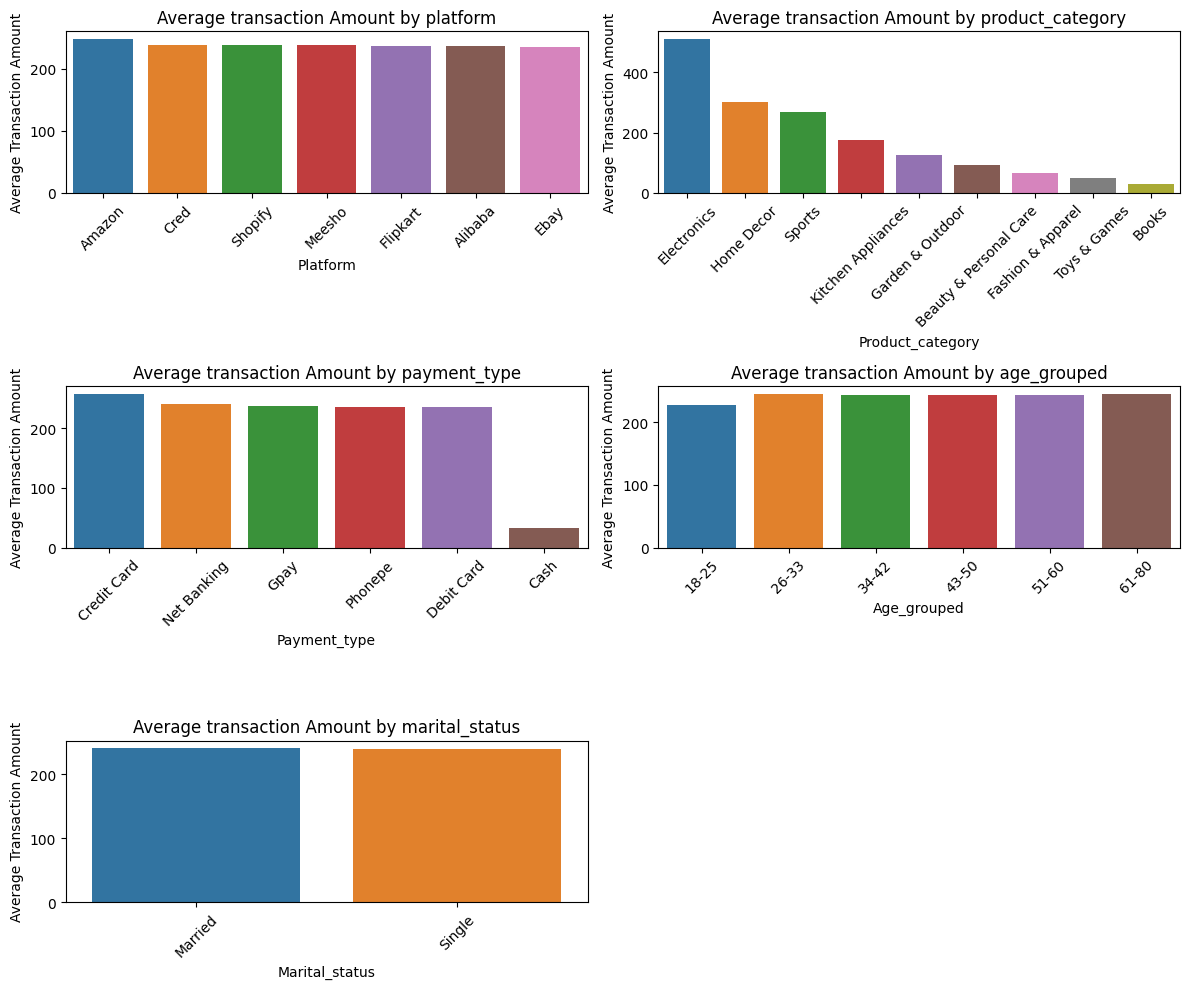

In [165]:
fig, axes = plt.subplots(3,2,figsize= (12,10))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    avg_tran_amount = (
        df_merged_2.groupby(col)['tran_amount'].mean().reset_index().sort_values(by='tran_amount', ascending=False)
    )

    sns.barplot(x=col,y='tran_amount',data=avg_tran_amount,ax=axes[i],palette='tab10',ci=None )
    #sns.barplot(x=col,y='tran_amount',data = df_merged_2,estimator=np.mean,ax=axes[i],palette='tab10')
    axes[i].set_title(f"Average transaction Amount by {col}")
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel("Average Transaction Amount")
    axes[i].tick_params(axis='x', rotation=45)

# Removing any empty subplot
for j in range(len(cat_col), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("visuals/Avg_trans_amount.png")
plt.show()

### Detailed Analysis on age group
we will find credit_limit, annual_income and credit_score for age groups.

In [166]:
age_group_mean = df_merged_2.groupby('age_grouped')[['credit_limit','annual_income','credit_score']].mean().reset_index()
age_group_mean

,age_grouped,credit_limit,annual_income,credit_score
0,18-25,1146.855728,37176.103883,483.608703
1,26-33,19297.785967,139454.162313,588.791879
2,34-42,21468.990800,154306.253772,610.180574
3,43-50,25937.738953,168187.106028,617.398240
4,51-60,42645.686576,263963.726371,703.287116
5,61-80,44820.988271,279598.548640,728.317444


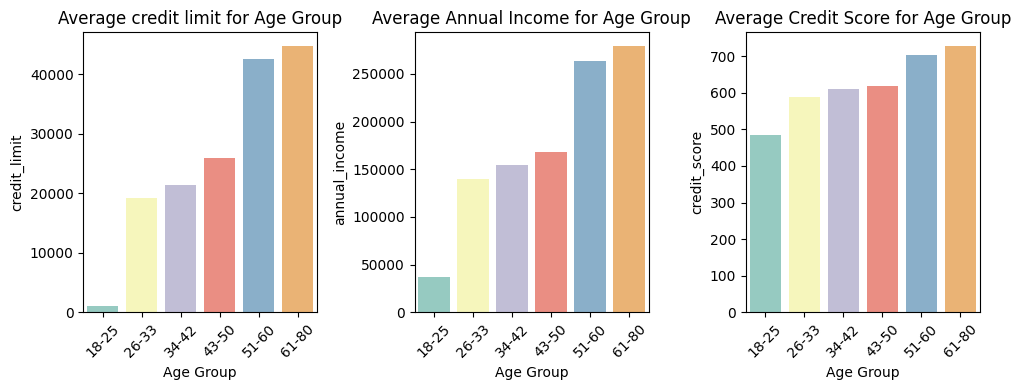

In [168]:
# Visualization

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

sns.barplot(x='age_grouped',y='credit_limit',data=age_group_mean,palette='Set3',ax=axes[0])
axes[0].set_title("Average credit limit for Age Group")
axes[0].set_xlabel("Age Group")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x='age_grouped',y='annual_income',data=age_group_mean,palette='Set3',ax=axes[1])
axes[1].set_title("Average Annual Income for Age Group")
axes[1].set_xlabel("Age Group")
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(x='age_grouped',y='credit_score',data=age_group_mean,palette='Set3',ax=axes[2])
axes[2].set_title("Average Credit Score for Age Group")
axes[2].set_xlabel("Age Group")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("Analysis_Age_group.png")
plt.show()

<h2 align="center" style="color:green; text-decoration:underline; font-weight:bold;">
  Finalize Target Market For a Trial Credit Card Launch
</h2>


### Exploring Unreached Market Segments

![Image 1](image1.png)
![Image 2](image2.png)

### Insights for Age Group 18–25:

1. Individuals aged 18–25 make up approximately 26% of the total customer base.

2. Their average annual income is below ₹50,000.

3. They have limited credit history, which is reflected in their lower credit scores and credit limits.

4. The usage of credit cards as a payment method is relatively lower compared to other age groups.

5. The top three product categories they shop for are Electronics, Fashion & Apparel, and Beauty & Personal Care.